# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

In [1]:
### ADD YOUR CODE HERE ###
import pandas as pd
data = pd.read_csv('household_power_consumption.txt', delimiter=';' )


data['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')
data.drop(columns=['Date', 'Time'], inplace=True)
data.set_index('DateTime', inplace=True)
print(data.head())
print("Number of samples", len(data))

print("Number of features", data.shape[1])

print(data.describe())

C:\Users\DARSHAN SONAWANE\AppData\Local\Temp\ipykernel_20520\1789281258.py:3: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('household_power_consumption.txt', delimiter=';' )


                    Global_active_power Global_reactive_power  Voltage  \
DateTime                                                                 
2006-12-16 17:24:00               4.216                 0.418  234.840   
2006-12-16 17:25:00               5.360                 0.436  233.630   
2006-12-16 17:26:00               5.374                 0.498  233.290   
2006-12-16 17:27:00               5.388                 0.502  233.740   
2006-12-16 17:28:00               3.666                 0.528  235.680   

                    Global_intensity Sub_metering_1 Sub_metering_2  \
DateTime                                                             
2006-12-16 17:24:00           18.400          0.000          1.000   
2006-12-16 17:25:00           23.000          0.000          1.000   
2006-12-16 17:26:00           23.000          0.000          2.000   
2006-12-16 17:27:00           23.000          0.000          1.000   
2006-12-16 17:28:00           15.800          0.000          

<span style='color:green'>### YOUR ANSWER ###</span>

2. Identify any missing values.

In [2]:
### ADD YOUR CODE HERE ###
print(data.isnull().sum())

Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


3. Handle any missing values (imputation or removal).

In [ ]:
### ADD YOUR CODE HERE ###
import pandas as pd
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce', downcast='float')

means = data[cols].mean()

data[cols] = data[cols].fillna(means)

print(data.isnull().sum())
print(data[cols].dtypes)



Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
Global_active_power      float32
Global_reactive_power    float32
Voltage                  float32
Global_intensity         float32
Sub_metering_1           float32
Sub_metering_2           float32
Sub_metering_3           float32
dtype: object


4. Create at least three different visualizations to explore the dataset.

datetime64[ns]
float32


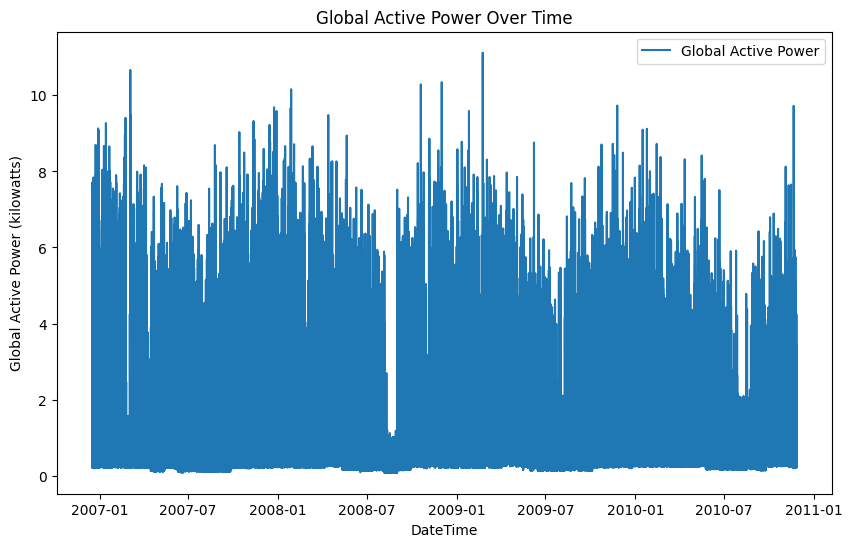

In [ ]:
import matplotlib.pyplot as plt

print(data.index.dtype)
print(data['Global_active_power'].dtype)

plt.figure(figsize=(10, 6))
plt.plot(data['Global_active_power'], label='Global Active Power')
plt.title('Global Active Power Over Time')
plt.xlabel('DateTime')
plt.ylabel('Global Active Power (kilowatts)')
plt.legend()
plt.show()


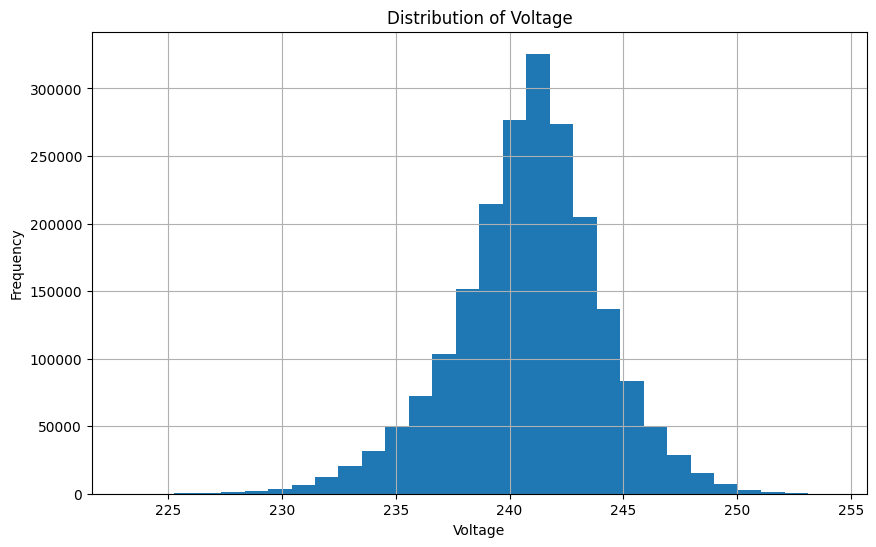

In [5]:
plt.figure(figsize=(10, 6))
data['Voltage'].hist(bins=30)
plt.title('Distribution of Voltage')
plt.xlabel('Voltage')
plt.ylabel('Frequency')
plt.show()

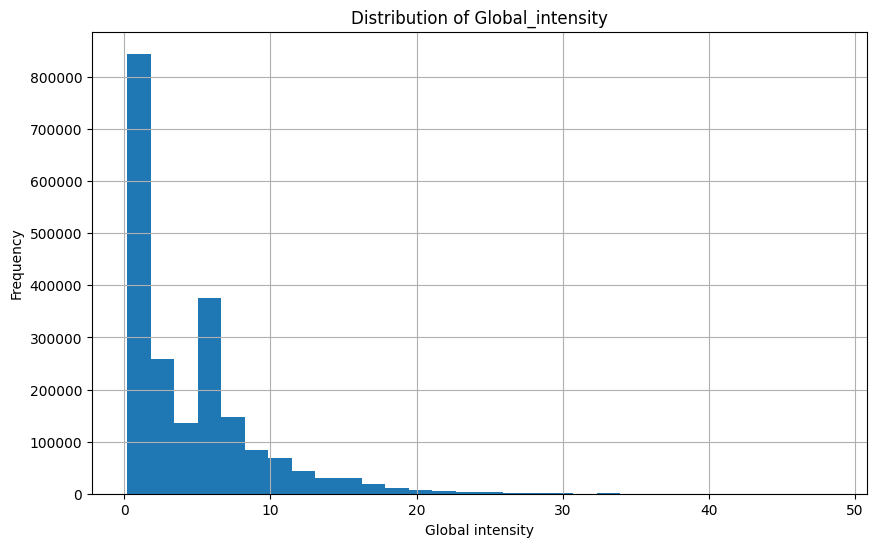

In [6]:
plt.figure(figsize=(10, 6))
data['Global_intensity'].hist(bins=30)
plt.title('Distribution of Global_intensity')
plt.xlabel('Global intensity')
plt.ylabel('Frequency')
plt.show()

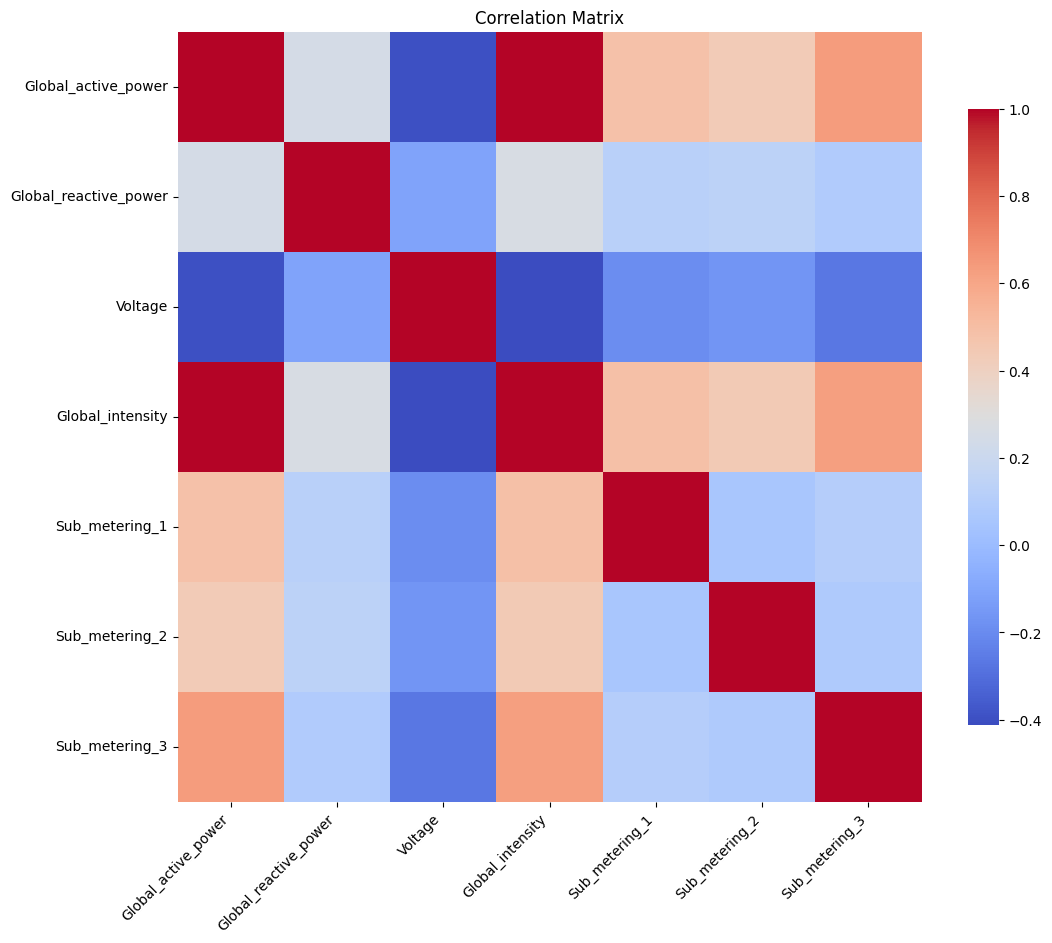

In [7]:
import seaborn as sns

corr_matrix = data.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink': .8})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Matrix')
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

5. Normalize or standardize your data using appropriate techniques.

In [ ]:
### ADD YOUR CODE HERE ###
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled)

print(data_scaled.head())

          0         1         2         3    4       5         6
0  0.374796  0.300719  0.376091  0.377593  0.0  0.0125  0.548387
1  0.478363  0.313669  0.336995  0.473029  0.0  0.0125  0.516129
2  0.479631  0.358273  0.326009  0.473029  0.0  0.0250  0.548387
3  0.480898  0.361151  0.340549  0.473029  0.0  0.0125  0.548387
4  0.325005  0.379856  0.403231  0.323651  0.0  0.0125  0.548387


6. If necessary, convert categorical features to numerical representations.

In [9]:
### ADD YOUR CODE HERE ###

7. Split the data into training, validation, and testing sets.

In [ ]:
### ADD YOUR CODE HERE ###
train_size = int(len(data_scaled) * 0.7)
val_size = int(len(data_scaled) * 0.15)
test_size = len(data_scaled) - train_size - val_size

train_data = data_scaled.iloc[:train_size]
val_data = data_scaled.iloc[train_size:train_size+val_size]
test_data = data_scaled.iloc[train_size+val_size:]

print("Train set shape:", train_data.shape)
print("Validation set shape:", val_data.shape)
print("Test set shape:", test_data.shape)


Train set shape: (1452681, 7)
Validation set shape: (311288, 7)
Test set shape: (311290, 7)


8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [ ]:
### ADD YOUR CODE HERE ###
import numpy as np
import torch
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [ ]:
n_steps = 10
X_train, y_train = create_sequences(train_data.values, n_steps)
X_val, y_val = create_sequences(val_data.values, n_steps)
X_test, y_test = create_sequences(test_data.values, n_steps)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1452671, 10, 7)
Validation set shape: (311278, 10, 7)
Testing set shape: (311280, 10, 7)


## Step 2: Model development

1. Choose either an RNN or LSTM network for your time-series forecasting task.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
import torch.nn as nn
from torchinfo import summary
import torch.optim as optim

class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_prob):
        super(RNNModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.dropout_prob = dropout_prob

        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout_prob, bidirectional=True)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)
        
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.rnn(x, h0)

        out = self.dropout(self.relu(self.fc1(out[:, -1, :])))
        out = self.fc2(out)
        return out

# Instantiate and use the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#Hyperparamter Tuning
model = RNNModel(input_dim=7, hidden_dim=100, num_layers=3, output_dim=7, dropout_prob=0.7)
# model = RNNModel(input_dim=7, hidden_dim=100, num_layers=3, output_dim=7, dropout_prob=0.2)
model.to(device)

#Hyperparamter Tuning
optimizer = optim.Adam(model.parameters(), lr=0.001)
# optimizer = optim.Adam(model.parameters(), lr=0.01)

criterion = nn.MSELoss()

print(summary(model, input_size=(64, 10, 7)))


Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 7]                   --
├─RNN: 1-1                               [64, 10, 200]             142,600
├─Linear: 1-2                            [64, 100]                 20,100
├─ReLU: 1-3                              [64, 100]                 --
├─Dropout: 1-4                           [64, 100]                 --
├─Linear: 1-5                            [64, 7]                   707
Total params: 163,407
Trainable params: 163,407
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 92.60
Input size (MB): 0.02
Forward/backward pass size (MB): 1.08
Params size (MB): 0.65
Estimated Total Size (MB): 1.75


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float() 

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).float()

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()  

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


#Hyperparamter Tuning
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) 


In [16]:
print(y_train.shape)
print(y_val.shape)


(1452671, 7)
(311278, 7)


2. Train your model using an appropriate loss function and optimizer.

In [17]:
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [ ]:
def compute_metrics(outputs, labels):
    mae = mean_absolute_error(labels, outputs)
    mse = mean_squared_error(labels, outputs)
    rmse = np.sqrt(mse)
    r2 = r2_score(labels, outputs)
    return mae, rmse, r2

In [ ]:
for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    
    print("Input shape:", inputs.shape)
    outputs = model(inputs)
    print("Output shape:", outputs.shape)
    print("Label shape:", labels.shape)

    break

Input shape: torch.Size([64, 10, 7])
Output shape: torch.Size([64, 7])
Label shape: torch.Size([64, 7])


In [20]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/assignment_1_part3')


In [ ]:
v_loss = []
t_loss= []

def train_and_validate(model, train_loader, val_loader, num_epochs, criterion, optimizer, device):
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        best_val_loss = float('inf')
        patience = 2
        patience_counter = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        t_loss.append(avg_train_loss)
        writer.add_scalar('Loss/Train', avg_train_loss, epoch)

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        v_loss.append(avg_val_loss)
        writer.add_scalar('Loss/Validation', avg_val_loss, epoch)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

        # Save the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print("Saved Best Model")

        else:
            patience_counter += 1
            print(f'No improvement in validation loss for {patience_counter} epoch(s).')
            if patience_counter >= patience:
                print('Early stopping triggered.')
                break
        writer.close()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def compute_accuracy(outputs, labels, threshold=0.1):
    return np.mean(np.abs(outputs - labels) <= threshold)

def evaluate_test_set(model, test_loader, criterion, device):
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.to(device)
    model.eval()

    total_test_loss = 0
    all_test_outputs = []
    all_test_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            all_test_outputs.append(outputs.detach().cpu())
            all_test_labels.append(labels.detach().cpu())

    all_test_outputs = torch.cat(all_test_outputs).numpy()
    all_test_labels = torch.cat(all_test_labels).numpy()

    test_mae, test_rmse, test_r2 = compute_metrics(all_test_outputs, all_test_labels)
    test_accuracy = compute_accuracy(all_test_outputs, all_test_labels)
    print(f'Test Loss: {total_test_loss / len(test_loader):.4f}')
    print(f'Test Metrics - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print("Number of test samples:", len(all_test_labels))
    print("Variance of test labels:", np.var(all_test_labels))

    plt.figure(figsize=(10, 6))
    plt.scatter(all_test_labels, all_test_outputs, alpha=0.5, label='Predicted vs. Actual')
    plt.plot([all_test_labels.min(), all_test_labels.max()], [all_test_labels.min(), all_test_labels.max()], 'r--')
    plt.title('Predicted v/s Actual Values on Test Dataset')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch [1/5], Train Loss: 0.0035, Validation Loss: 0.0016
Saved Best Model
Epoch [2/5], Train Loss: 0.0032, Validation Loss: 0.0013
Saved Best Model
Epoch [3/5], Train Loss: 0.0032, Validation Loss: 0.0019
Saved Best Model
Epoch [4/5], Train Loss: 0.0032, Validation Loss: 0.0015
Saved Best Model
Epoch [5/5], Train Loss: 0.0032, Validation Loss: 0.0016
Saved Best Model


C:\Users\DARSHAN SONAWANE\AppData\Local\Temp\ipykernel_20520\745999656.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'

Test Loss: 0.0014
Test Metrics - MAE: 0.0213, RMSE: 0.0377, R2: 0.8281
Test Accuracy: 0.9799
Number of test samples: 311280
Variance of test labels: 0.048182424


C:\Users\DARSHAN SONAWANE\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


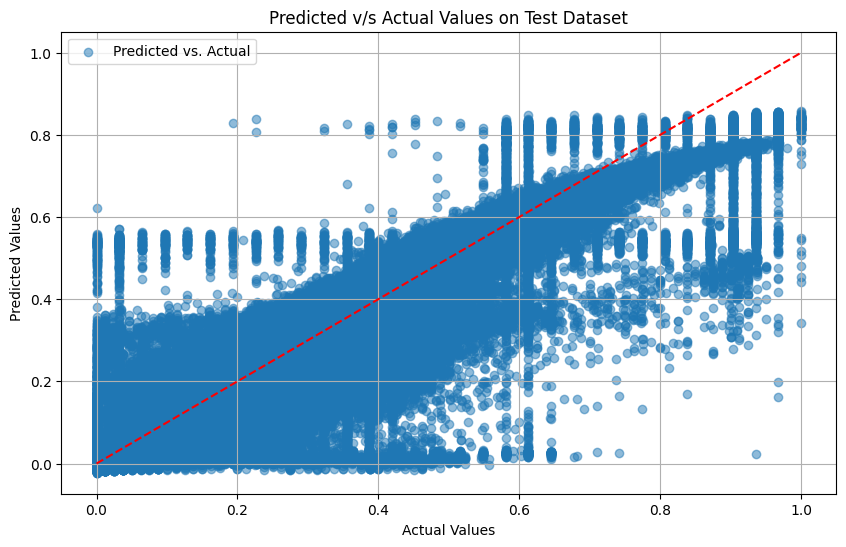

In [ ]:
#Hyperparamter Tuning
train_and_validate(model, train_loader, val_loader, 5, criterion, optimizer, device)
evaluate_test_set(model, test_loader, criterion, device)

In [ ]:
#Hyperparamater Tuning Strategy used :- Manual Tuning
# Combination 1 :- batch size =32, learning rate = 0.001, dropout rate = 0.2
#Results :- Train Loss: 0.0012, Validation Loss: 0.0010, Test accuracy: 0.9873, Test Metrics - MAE: 0.0154, RMSE: 0.0301, R2: 0.8867

#Combination 2 :- batch size = 64, learning rate = 0.001, dropout rate = 0.7
#Results :- Train Loss: 0.0032, Validation Loss: 0.0016, Test Loss: 0.0014 Test Metrics - MAE: 0.0213, RMSE: 0.0377, R2: 0.8281, Test Accuracy: 0.9799

In [ ]:
for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    
    print("Input shape:", inputs.shape)
    outputs = model(inputs)
    print("Output shape:", outputs.shape)
    print("Label shape:", labels.shape)

    break


Input shape: torch.Size([64, 10, 7])
Output shape: torch.Size([64, 7])
Label shape: torch.Size([64, 7])


3. Save the weights of the trained neural network that provides the best results.

In [26]:
### ADD YOUR CODE HERE ###
# Already done in the previous step

## Step 3: Evaluation and analysis

1. Evaluate your trained model on the test set.

Already performed evaluation in step 2


Train Loss: 0.0032, Validation Loss: 0.0016, Test Loss: 0.0014

2. Report relevant metrics.

Test Metrics - MAE: 0.0213, RMSE: 0.0377, R2: 0.8281
Test Accuracy: 0.9799


3. Provide various plots.

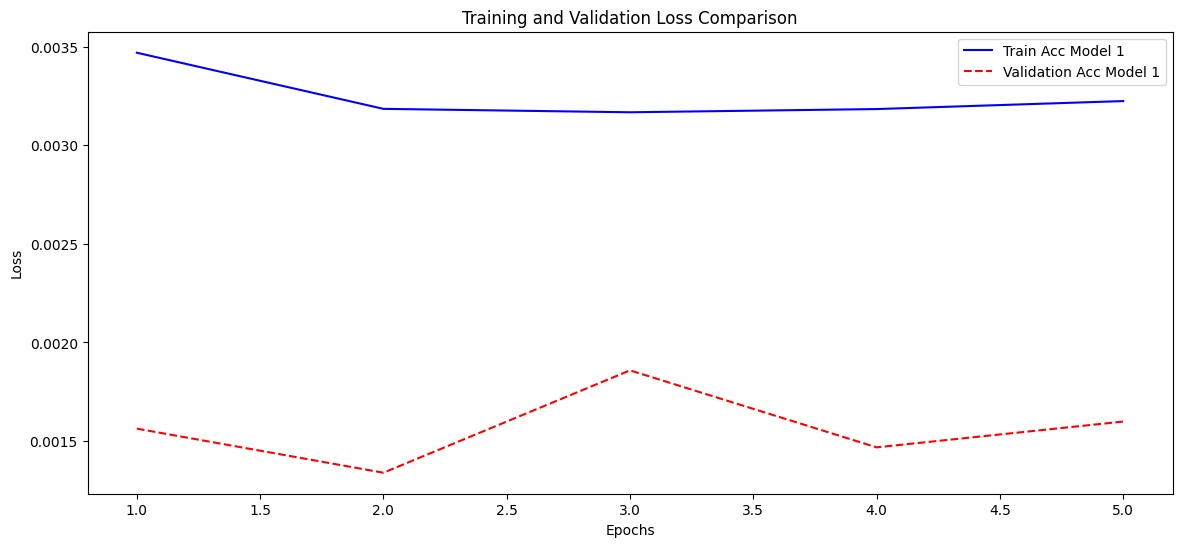

In [27]:
### ADD YOUR CODE HERE ###
epochs = range(1, len(t_loss) + 1)
plt.figure(figsize=(14, 6))
plt.plot(epochs, t_loss, 'b-', label='Train Acc Model 1')
plt.plot(epochs, v_loss, 'r--', label='Validation Acc Model 1')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Plotted another graph in the evaluate_test_set function

4. Discuss and analyze.

Briefly reiterate the key characteristics of your dataset.

The dataset named 'household_power_consumption.txt' tracks the power consumption of a house over a period of time
Key characteristics :-
Variables in the dataset :- Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1, Sub_metering_2, Sub_metering_3, Date, Time

For performing time-series analysis the data is indexed by DateTime, providing a timestamp for each reading.

Statistical Overview of data :-
Number of samples 2075259
Number of features 7
Number of null values by each column :-
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64



Describe your final RNN/LSTM architecture in detail (number of layers, types
of layers, hidden size, dropout rate, etc.).


A bidirectional RNN is utilized here. Bidirectionality allows the network to get information from both past i.e forward pass and future i.e backward pass states simultaneously, enhancing the learning context.

input dimension = 7
hidden dimension = 100
number of layers = 3
output dimension = 7
dropout rate = 0.2

Activation function used :- ReLU which introduces non-linearity into the model, 
enhancing its ability to learn more complex patterns.

Number of fully connected layers = 2 i.e fc1, fc2
fc1 maps the output from the bidirectional RNN which is doubled due to the bidirectional setup, thus hidden_dim * 2 to the hidden_dim.
fc2 maps the hidden representation to the final output dimension, which predicts the same 7 features as the inputs.
Number of epochs for traning, validating the dataset = 5
Batch size of the train, test, validation sets = 32
The optimizer used is Adam with a learning rate of 0.001, which is a popular choice for RNNs due to its efficient handling of sparse gradients and adaptive learning rate properties.
The loss function is Mean Squared Error (MSE), suitable for regression.



Discuss your results, referencing the metrics and visualizations. Did your model
achieve the expected accuracy? What were the challenges? How did
hyperparameter tuning affect performance? Are there any patterns in the errors
(e.g., consistent under- or over-prediction)?

The model achieved the expected accuracy i.e above 75%.
The best test accuracy achieved is 98.73%

Challenges :-
Generalization: Higher dropout rates, as in Combination 2, can help with generalization but might have contributed to slightly reduced performance metrics due to the loss of some useful features during training.

Hyperparameter Tuning Impact :-
Increasing the dropout rate from 0.2 to 0.7 seems to have impacted the model's ability to learn more complex patterns effectively, as seen from the lower test metrics in Combination 2.

The increase in batch size from 32 to 64 could have affected the gradient estimates during backpropagation, possibly smoothing out some learning details and impacting model sensitivity to smaller, yet significant, feature variations.

Error Pattern Analysis :-
There are not any obervable patterns in the errors

Discuss any limitations of your model or approach.

1. Vanishing Gradient Problem
The model is susceptible to the vanishing gradient problem, where gradients become very small, effectively preventing weights from changing their values during backpropagation. This can severely limit the learning capacity of the model, particularly for long input sequences.

2. Generalization Capability
High dropout rates, such as 0.7 help prevent overfitting but can also lead to underfitting, where the model fails to learn important patterns in the training data.

Suggest potential improvements or future work (e.g., trying different
architectures, incorporating more features, using a more sophisticated data
preprocessing pipeline).

Replacing the basic RNN layers with Long Short-Term Memory (LSTM) or Gated Recurrent Unit (GRU) layers can obtain better resukts since these are designed tocapture better long-range dependencies and are more effective in avoiding the vanishing gradient problem.

For time-series data, techniques like windowing, noise injection, or even synthetic data generation using approaches like SMOTE for time series can significantly improve the training dataset and improve model robustness.

Implementing learning rate schedulers which reduce the learning rate as the training progresses, helping to fine-tune the model's weights more effectively in the later stages of training.

<span style='color:green'>### YOUR ANSWER ###</span>

5. References.
https://www.geeksforgeeks.org/time-series-forecasting-using-pytorch/
https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/
https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/?ref=ml_lbp
https://www.geeksforgeeks.org/bidirectional-recurrent-neural-network/
https://www.w3schools.com/python/matplotlib_pyplot.asp
https://pytorch.org/docs/stable/generated/torch.from_numpy.html
https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption




<span style='color:green'>### YOUR ANSWER ###</span>